In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [61]:
g = 9.8
H0 = 100 #deepest point
alpha = 0.01 #slope of the shore
hh = 50 #headland height
Lx = 4000 #domain length
Ly = 4000 #domain width
Lh = 1000 #headland width

def Headland(x,y):
    return np.maximum(H0 - alpha *x - hh * np.exp(-(y/Lh)**2) * np.exp(-((x-Lx)/(Lx/2))**2), 0.5)

def beach(x,y):
    return np.maximum(H0 - alpha * x, 0.5)

def Omega(kx, ky, x, y, H=Headland):
    k = np.sqrt(kx**2 + ky**2)
    return np.sqrt(g * H(x,y)) * k 

def ray_trace(x0, y0, kx0, ky0, seafloor): #this uses generic seafloor function so we can do headland and sloping beach
    t_final = 300
    dt = 0.5
    dx = 1.0 # for numerical derivative
    dy = 1.0 # for numerical derivative
    N = int(t_final/dt)
    x = x0.copy()
    y = y0.copy()
    kx = kx0.copy()
    ky = ky0.copy()
    x_traj = [x.copy()]
    y_traj = [y.copy()]
    kx_traj = [kx.copy()]
    ky_traj = [ky.copy()]

    for n in range(N):
       # define domega/dx and domega/dy
       k = np.sqrt(kx**2 + ky**2)
       dHdx = (seafloor(x + dx, y) - seafloor(x - dx, y)) / (2*dx) #using central difference to approximate derivative
       dHdy = (seafloor(x, y + dy) - seafloor(x, y - dy)) / (2*dy)
       dOmegadx = 0.5 * np.sqrt(g/seafloor(x,y)) * k * dHdx
       dOmegady = 0.5 * np.sqrt(g/seafloor(x,y)) * k * dHdy

       dOmegadkx = 0.5 * np.sqrt(g * seafloor(x,y)) * (kx/k)
       dOmegadky = 0.5 * np.sqrt(g * seafloor(x,y)) * (ky/k)

       #update x, y, kx, ky using forward euler
       kx_new = kx + dt * (-dOmegadx)
       ky_new = ky + dt * (-dOmegady)
       x_new = x + dt * dOmegadkx
       y_new = y + dt * dOmegadky

       #store and update
       kx, ky, x, y = kx_new, ky_new, x_new, y_new
       x_traj.append(x.copy())
       y_traj.append(y.copy())
       kx_traj.append(kx.copy())
       ky_traj.append(ky.copy())

    t_traj = np.arange(0, (N+1)*dt, dt)

    return t_traj, np.array(x_traj), np.array(y_traj), np.array(kx_traj), np.array(ky_traj)

Text(0, 0.5, 'y (m)')

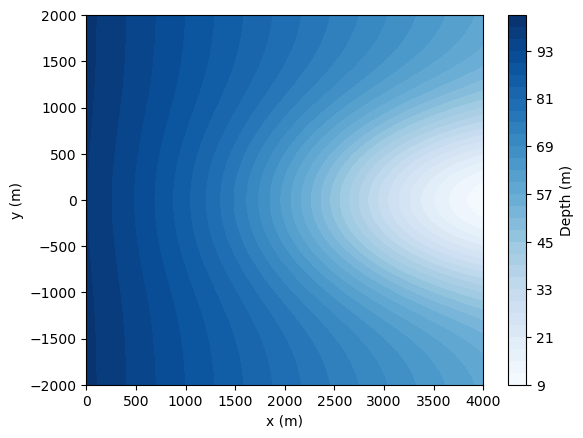

In [42]:
#visualization of headland 
xx = np.linspace(0, Lx, 200)
yy = np.linspace(-Ly/2, Ly/2, 200)
X, Y = np.meshgrid(xx, yy)
plt.contourf(X, Y, Headland(X,Y), cmap='Blues', levels=30)
plt.colorbar(label='Depth (m)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')

Text(0, 0.5, 'y (m)')

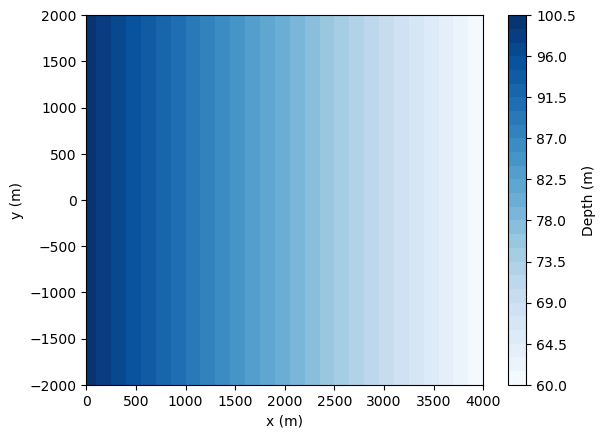

In [43]:
#visualization of beach
plt.contourf(X, Y, beach(X,Y), cmap='Blues', levels=30)
plt.colorbar(label='Depth (m)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')

In [62]:
#inital conditions
y0 = np.linspace(-Ly/2, Ly/2, 15) #initial y positions, so this means we have 15 rays
x0 = np.ones_like(y0) * 10 #initial x positions, all start at x=10
kx0 = np.ones_like(y0) * 0.1 #all rays start with same kx
ky0 = np.ones_like(y0) * 0.0
t_traj, x_traj, y_traj, kx_traj, ky_traj = ray_trace(x0, y0, kx0, ky0, seafloor=beach)

t_trajH, x_trajH, y_trajH, kx_trajH, ky_trajH = ray_trace(x0, y0, kx0, ky0, seafloor=Headland)

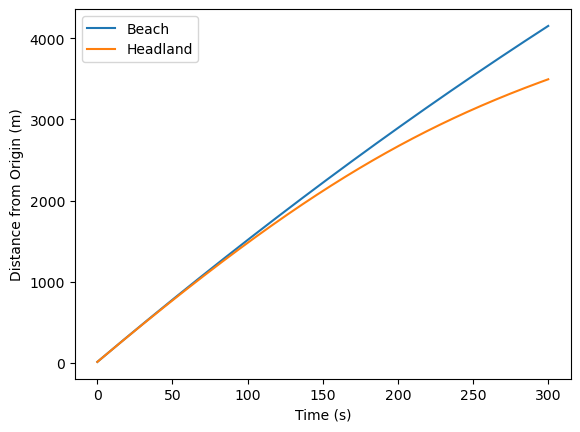

In [73]:
pos = np.sqrt(np.square(x_traj[:, len(y0)//2]) + np.square(y_traj[:, len(y0)//2]))
posH = np.sqrt(np.square(x_trajH[:, len(y0)//2]) + np.square(y_trajH[:, len(y0)//2]))
plt.plot(t_traj, pos, label='Beach')
plt.plot(t_trajH, posH, label='Headland')
plt.xlabel('Time (s)')
plt.ylabel('Distance from Origin (m)')
plt.legend()

In [71]:
kH = np.sqrt(np.square(ky_trajH[:,len(y0)//2]) + np.square(kx_trajH[:,len(y0)//2]))
k = np.sqrt(np.square(ky_traj[:,len(y0)//2]) + np.square(kx_traj[:,len(y0)//2]))

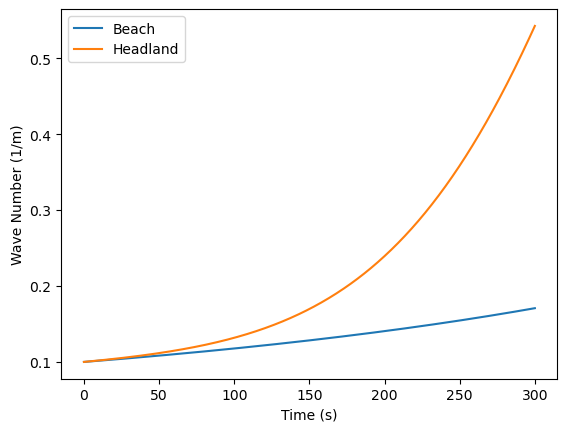

In [72]:
plt.plot(t_traj, k, label='Beach')
plt.plot(t_trajH, kH, label='Headland')
plt.xlabel('Time (s)')
plt.ylabel('Wave Number (1/m)')
plt.legend()

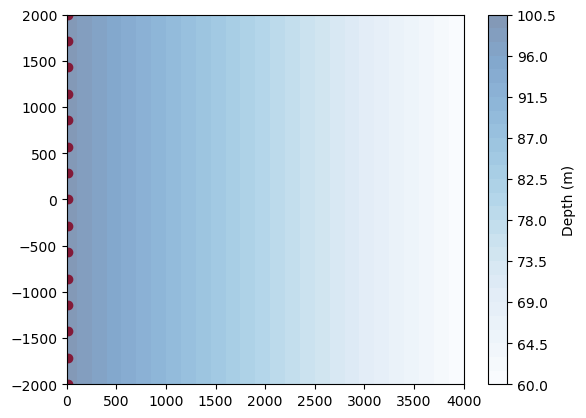

In [56]:
plt.figure()
for i in range(len(y0)):
    plt.scatter(x_traj[0,i], y_traj[0,i], color='red') #plot initial positions

plt.contourf(X, Y, beach(X,Y), cmap='Blues', levels=30, alpha=0.5)

plt.colorbar(label='Depth (m)')

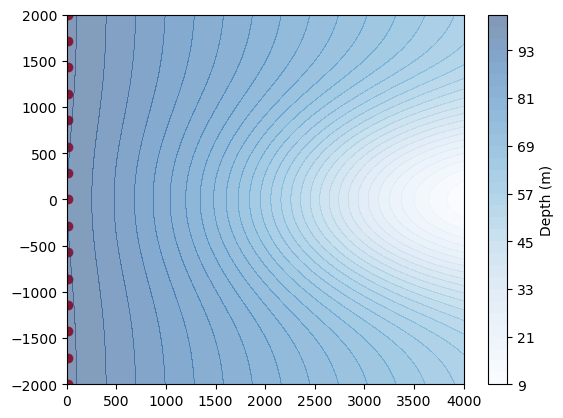

In [57]:
plt.figure()
for i in range(len(y0)):
    plt.scatter(x_trajH[0,i], y_trajH[0,i], color='red') #plot initial positions

plt.contourf(X, Y, Headland(X,Y), cmap='Blues', levels=30, alpha=0.5)

plt.colorbar(label='Depth (m)')

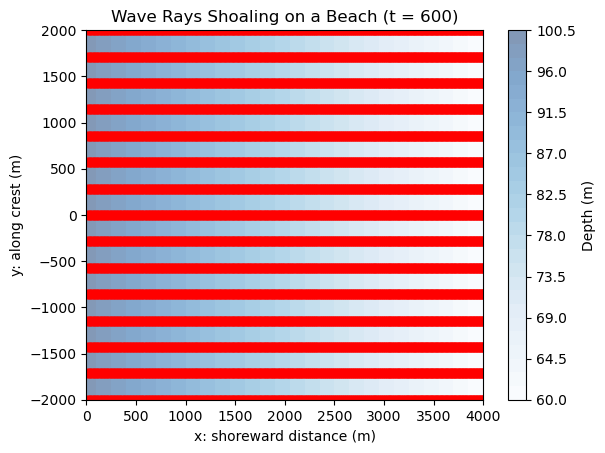

In [54]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()
contour = ax.contourf(X, Y, beach(X,Y), cmap='Blues', levels=30, alpha=0.5)
plt.colorbar(contour, label='Depth (m)')

#initial ray positions
points = []
for i in range(len(y0)):
    point, = ax.plot(x_traj[0,i], y_traj[0,i], 'ro')
    points.append(point)

ax.set_title("Wave Rays Shoaling on a Beach")
ax.set_xlabel("x: shoreward distance (m)")
ax.set_ylabel("y: along crest (m)")
ax.set_xlim(0, Lx)
ax.set_ylim(-Ly/2, Ly/2)

def update(frame):
    for i, point in enumerate(points):
        point.set_data(x_traj[:frame,i], y_traj[:frame,i])
    ax.set_title(f"Wave Rays Shoaling on a Beach (t = {frame})")
    return points

anim = animation.FuncAnimation(fig, update, frames=len(x_traj), interval=30, blit=True)

anim.save("SWW_beach.gif", fps=30, writer="pillow")


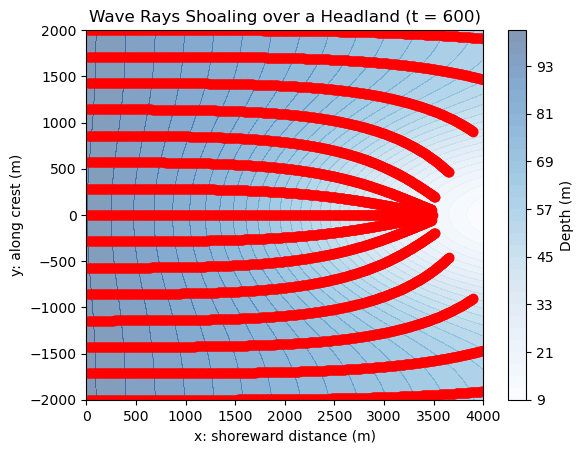

In [55]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()
contour = ax.contourf(X, Y, Headland(X,Y), cmap='Blues', levels=30, alpha=0.5)
plt.colorbar(contour, label='Depth (m)')

#initial ray positions
points = []
for i in range(len(y0)):
    point, = ax.plot(x_trajH[0,i], y_trajH[0,i], 'ro')
    points.append(point)

ax.set_title("Wave Rays Shoaling over a Headland")
ax.set_xlabel("x: shoreward distance (m)")
ax.set_ylabel("y: along crest (m)")
ax.set_xlim(0, Lx)
ax.set_ylim(-Ly/2, Ly/2)

def update(frame):
    for i, point in enumerate(points):
        point.set_data(x_trajH[:frame,i], y_trajH[:frame,i])
    ax.set_title(f"Wave Rays Shoaling over a Headland (t = {frame})")
    return points

anim = animation.FuncAnimation(fig, update, frames=len(x_trajH), interval=80, blit=True)

anim.save("SWW_Headland.gif", fps=30, writer="pillow")